<a href="https://colab.research.google.com/github/Mohamad-Selawy/Python/blob/master/Data%20Analysis/Level%203/Part_1_Fundamentals_and_Matplotlib_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Data Visualization Module: Part 1 - Fundamentals and Matplotlib Basics

Welcome to the first part of our Data Visualization module! In this notebook, we'll embark on a journey to understand the importance of visualizing data, explore fundamental principles, and get hands-on with Matplotlib, a powerful Python library for creating static, interactive, and animated visualizations.

This module is designed for beginners, focusing on clear explanations and practical examples using the Superstore Dataset.

In [45]:
import kagglehub
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

Using Colab cache for faster access to the 'sales-forecasting' dataset.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# The 'path' variable is provided by the Kaggle API download.
# Let's inspect the files in this directory to find the main dataset file.
print(f"Files found in the dataset directory: {os.listdir(path)}")

# Assuming the primary CSV file is directly in the downloaded path
# We'll try to find a common CSV name or pick the first one.
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the dataset directory.")

datafile = csv_files[0] # Take the first CSV file found

try:
    # Attempt to read the CSV. Common encodings are 'utf-8' or 'latin1'.
    # We'll try 'utf-8' first, then 'latin1' if it fails.
    try:
        df_orders = pd.read_csv(f"{path}/{datafile}")
        print(f"Dataset '{datafile}' loaded successfully with utf-8 encoding!")
    except UnicodeDecodeError:
        df_orders = pd.read_csv(f"{path}/{datafile}", encoding='latin1')
        print(f"Dataset '{datafile}' loaded successfully with latin1 encoding!")
except FileNotFoundError:
    print(f"Error: '{datafile}' not found. Please ensure the correct file is present.")
    raise # Re-raise the error if the file is not found

# Display the first few rows of the DataFrame to confirm it's loaded correctly
display(df_orders.head())

# Display basic information about the DataFrame
display(df_orders.info())

Files found in the dataset directory: ['train.csv']
Dataset 'train.csv' loaded successfully with utf-8 encoding!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

None

In [47]:
df_orders = df_orders.dropna()
df_orders['Order Date'] = pd.to_datetime(df_orders['Order Date'], dayfirst=True)
df_orders['Ship Date'] = pd.to_datetime(df_orders['Ship Date'], dayfirst=True)
df_orders['Profit'] = df_orders['Sales'] * 0.2
df_orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,52.3920
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,146.3880
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.9240
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,191.5155
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,4.4736


# 1. Introduction to Data Visualization

Data visualization is a cornerstone of data analysis. It's the art and science of representing data in a graphical format, making complex information accessible and understandable.

### What is Data Visualization?

Data visualization is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, data visualization tools provide an accessible way to see and understand trends, outliers, and patterns in data. It transforms raw data into insights, allowing for quicker decision-making and better comprehension.

### Why Visualization is Important in Data Analysis

1.  **Simplifies Complex Data**: Humans are visual creatures. Our brains are hardwired to process visual information much faster than text or numbers. Visualizations condense large datasets into easily digestible formats.
2.  **Identifies Patterns and Trends**: It helps in spotting correlations, trends, and anomalies that might be hidden in raw data.
3.  **Facilitates Decision Making**: By presenting insights clearly, visualizations empower stakeholders to make informed decisions quickly.
4.  **Communicates Insights Effectively**: It serves as a powerful communication tool, enabling data analysts to share their findings with a non-technical audience.
5.  **Uncovers Hidden Insights**: Sometimes, a visual representation can reveal unexpected relationships or problems within the data that purely statistical methods might miss.

### The Role of Visualization in the Data Analysis Workflow

Data visualization plays a crucial role at various stages of the data analysis workflow:

*   **Data Cleaning and Preprocessing**: Visualizations can help identify outliers, missing values, and data inconsistencies.
*   **Exploratory Data Analysis (EDA)**: This is where visualization truly shines, allowing analysts to understand data distributions, relationships between variables, and to formulate hypotheses.
*   **Model Building and Evaluation**: Visualizations can help assess model performance, compare different models, and understand feature importance.
*   **Reporting and Communication**: Presenting findings to stakeholders, making complex analytical results understandable and actionable.

### Exploratory vs Explanatory Visualization

It's important to distinguish between these two modes of visualization:

*   **Exploratory Visualization**: This is used during the initial stages of data analysis. Its purpose is to help the analyst understand the data, find patterns, and generate hypotheses. It's often messy, iterative, and for an internal audience (the analyst themselves or their immediate team).
    *   **Example**: Plotting various combinations of variables to see if any relationships emerge.

*   **Explanatory Visualization**: This is used to communicate findings and insights to an audience. Its purpose is to tell a clear, concise story and persuade or inform. It's typically polished, well-annotated, and designed for an external audience.
    *   **Example**: A dashboard or a report chart highlighting a key trend or a business recommendation.

### Overview of Visualization Libraries in Python

Python boasts a rich ecosystem of libraries for data visualization. Some of the most popular include:

*   **Matplotlib**: The foundational library for creating static, animated, and interactive visualizations in Python. It provides a highly flexible and comprehensive set of tools, giving users fine-grained control over every aspect of a plot.
*   **Seaborn**: Built on top of Matplotlib, Seaborn provides a high-level interface for drawing attractive and informative statistical graphics. It simplifies the creation of complex plots, especially those involving multiple variables.
*   **Plotly**: An interactive graphing library that makes publication-quality graphs online. It's excellent for creating interactive dashboards and web-based visualizations.

### Matplotlib vs Seaborn (High-Level Comparison)

| Feature           | Matplotlib                                         | Seaborn                                                         |
| :---------------- | :------------------------------------------------- | :-------------------------------------------------------------- |
| **Level of Abstraction** | Low-level: provides building blocks for plots      | High-level: provides high-level functions for specific plot types |
| **Syntax**        | More verbose, requires more code for complex plots | Concise, often single-line for common statistical plots         |
| **Default Aesthetics** | Basic, often requires customization for beauty     | Visually appealing defaults, designed for statistical graphics   |
| **Focus**         | General-purpose plotting                           | Statistical data visualization                                  |
| **Use Case**      | Fine-grained control, custom plots, foundational   | Quick statistical plots, aesthetically pleasing plots           |
| **Integration**   | Seaborn builds on Matplotlib                       | Uses Matplotlib for underlying rendering and customization      |

In this module, we will primarily focus on Matplotlib to build a strong foundational understanding of visualization in Python. Once you master Matplotlib, learning Seaborn will be much easier!

# 2. Visualization Principles

Creating effective visualizations goes beyond simply knowing how to use a library. It involves understanding how humans perceive information and adhering to design principles that ensure your message is communicated clearly and accurately.

### Characteristics of Good Visualizations

A good visualization should:

1.  **Be Accurate**: Represent data truthfully, avoiding distortion or misrepresentation.
2.  **Be Clear**: Easily understood without extensive explanation.
3.  **Be Concise**: Convey maximum information with minimum ink (data-ink ratio).
4.  **Be Engaging**: Capture and hold the viewer's attention.
5.  **Serve a Purpose**: Answer a question or tell a story.
6.  **Be Accessible**: Consider accessibility for all users, including those with visual impairments.
7.  **Be Ethically Responsible**: Avoid manipulative presentations that could mislead the audience.

### Human Visual Perception

Understanding how humans perceive visual information is crucial for effective data visualization. Our brains are naturally good at:

*   **Recognizing Patterns**: We quickly identify clusters, trends, and anomalies.
*   **Detecting Differences**: We notice variations in size, color, shape, and orientation.
*   **Spatial Relationships**: We understand proximity and relative positions.

However, our perception can also be misled. For example, comparing areas (like in pie charts) can be harder than comparing lengths (like in bar charts). Effective visualizations leverage our strengths and avoid our weaknesses.

### Choosing the Appropriate Chart

The type of chart you choose depends heavily on the type of data you have and the message you want to convey. Here's a general guide:

*   **Comparison (among items)**: Bar charts, stacked bar charts.
*   **Comparison (over time)**: Line charts.
*   **Distribution**: Histograms, box plots.
*   **Relationship (between two variables)**: Scatter plots.
*   **Composition (parts of a whole)**: Pie charts (for small number of categories), stacked bar charts.

We will explore these chart types in detail later in the notebook.

### Avoiding Misleading Charts

Even with good intentions, charts can unintentionally mislead. Be mindful of:

*   **Truncated Y-Axis**: Starting the y-axis at a value other than zero can exaggerate differences.
*   **Inappropriate Scaling**: Using scales that distort the true proportion of data.
*   **Cherry-picking Data**: Only showing data that supports a particular narrative.
*   **Complex or Cluttered Designs**: Too much information can overwhelm and confuse the viewer.
*   **Misleading Colors**: Using colors that imply a relationship that doesn't exist or evoke incorrect emotions.

### Simplicity and Clarity

The best visualizations are often the simplest. Strive for:

*   **Minimalism**: Remove unnecessary elements (chart junk).
*   **Directness**: Ensure the main message is immediately apparent.
*   **Consistency**: Use consistent formatting, colors, and labels across all charts.
*   **Legibility**: Ensure all text, including labels and annotations, is easy to read.

### Color Best Practices

Color is a powerful tool but must be used thoughtfully:

*   **Purposeful Use**: Use color to highlight, group, or differentiate data, not just to decorate.
*   **Color Palettes**: Choose palettes suitable for your data type:
    *   **Categorical**: Distinct colors for different categories.
    *   **Sequential**: Varying shades of a single color for ordered data.
    *   **Diverging**: Two distinct colors with a neutral midpoint for data with a critical value (e.g., above/below average).
*   **Accessibility**: Consider colorblindness; avoid relying solely on color to convey information. Use shape, texture, or labels as well.
*   **Cultural Meanings**: Be aware that colors can have different meanings across cultures.
*   **Limit Colors**: Too many colors can be overwhelming and confusing.

### Titles, Labels, Legends, and Annotations

These elements are crucial for making your visualization self-explanatory:

*   **Titles**: A concise and informative title tells the viewer what the chart is about. It should summarize the main takeaway or the question being answered.
*   **Axis Labels**: Clearly label both the X and Y axes, including units if applicable. This ensures the viewer understands what quantities are being represented.
*   **Legends**: When a chart displays multiple series or categories (e.g., different lines on a line chart, different colors on a bar chart), a legend explains what each visual element represents.
*   **Annotations**: Specific text or arrows added to a chart to draw attention to a particular data point, trend, or an important event. Annotations can provide additional context or highlight key insights directly on the plot.

# 3. Introduction to Matplotlib

Matplotlib is the most widely used plotting library in Python, providing a flexible foundation for creating a vast range of static, animated, and interactive visualizations. It was designed to mimic the plotting functions of MATLAB, making it familiar to many users with a scientific or engineering background.

### What Matplotlib Is

*   **Foundation**: Matplotlib is the bedrock upon which many other Python visualization libraries (like Seaborn) are built.
*   **Versatility**: It can create virtually any type of static plot, from simple line plots to complex 3D visualizations.
*   **Control**: It offers a high degree of control over every element of a plot, allowing for extensive customization.
*   **Interfaces**: It provides two main interfaces:
    *   **Pyplot (plt)**: A state-based interface that automatically creates figures and axes to achieve the desired plot. This is often used for quick and simple plots.
    *   **Object-Oriented (OO) Interface**: A more formal and powerful approach where you explicitly create `Figure` and `Axes` objects. This provides more control and is recommended for complex plots or when embedding plots in applications.

### Figure and Axes

Understanding the core components of a Matplotlib plot is essential. The two most fundamental objects are the **Figure** and the **Axes**.

*   **Figure**: Think of the Figure as the entire canvas or window in which your plot will be drawn. It can contain one or more `Axes` objects.
*   **Axes**: This is the actual plotting area where the data is drawn. It's the region of the image with the data space. A Figure can have multiple Axes, but a given `Axes` object can only be in one Figure. The `Axes` contains most of the plot elements: X-axis, Y-axis, labels, title, ticks, lines, points, etc.

Here's a visual analogy:

*   **Figure** = The whole piece of paper.
*   **Axes** = A single graph drawn on that paper (you can have multiple graphs on one piece of paper).

### Creating the First Plot

Let's create a simple plot using the `df_orders` DataFrame. We will plot 'Sales' against 'Order Date' to see if there's any immediate relationship.

We'll use the **Pyplot interface (`plt`)** as it's often more compact for simple plots and aligns with the current refactoring strategy for the notebook.

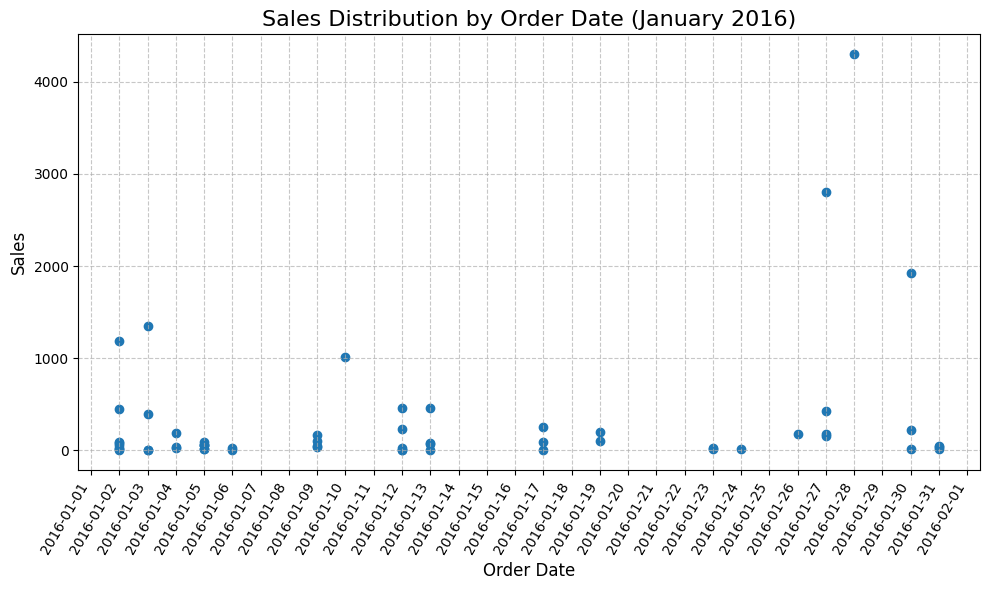

In [48]:
import matplotlib.ticker as mticker
# Create a simple plot using the pyplot interface
# We use plt.figure() to explicitly create a figure and specify its size.
# Then, we directly call plotting functions on plt.
plt.figure(figsize=(10, 6)) # Increased figure width for better date visibility

# Filter df_orders for sales in 2015
df_orders_2016 = df_orders[df_orders['Order Date'].between('2016-01-01','2016-01-31')]

# Plotting data directly using plt.scatter()
# 'df_orders['Order Date']' is assigned to the x-axis, 'Sales' to the y-axis.
plt.scatter(x=df_orders_2016['Order Date'], y=df_orders_2016['Sales'])

# Setting the title of the plot directly using plt.title()
plt.title('Sales Distribution by Order Date (January 2016)', fontsize=16)

# Setting the label for the x-axis using plt.xlabel()
plt.xlabel('Order Date', fontsize=12)

# Setting the label for the y-axis using plt.ylabel()
plt.ylabel('Sales', fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# --- Customize x-axis to display every day ---
import matplotlib.dates as mdates # Import the dates module from Matplotlib
# Get the current Axes object to modify its properties
plt.gca().xaxis.set_major_locator(mdates.DayLocator()) # Set major ticks for every day
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # Format the major tick labels as Year-Month-Day

# --- Customize y-axis using a locator ---
# Get the current Axes object for the y-axis
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(5)) # Set a maximum of 5 major ticks on the y-axis

# Rotate x-axis labels for better readability
plt.xticks(rotation=60, ha='right', fontsize = 10)

# Automatically adjusts spacing so that labels, titles, and ticks fit within the figure without being cut off.
# Without it, long rotated date labels might extend beyond the edge of the figure.
plt.tight_layout()

# Display the plot
plt.show()

### Saving Figures

Once you've created a plot, you'll often want to save it as an image file for reports, presentations, or sharing. Matplotlib's `Figure` object has a `savefig()` method that allows you to do this.

You can save figures in various formats like PNG, JPEG, PDF, SVG, etc. The file format is inferred from the extension you provide in the filename.

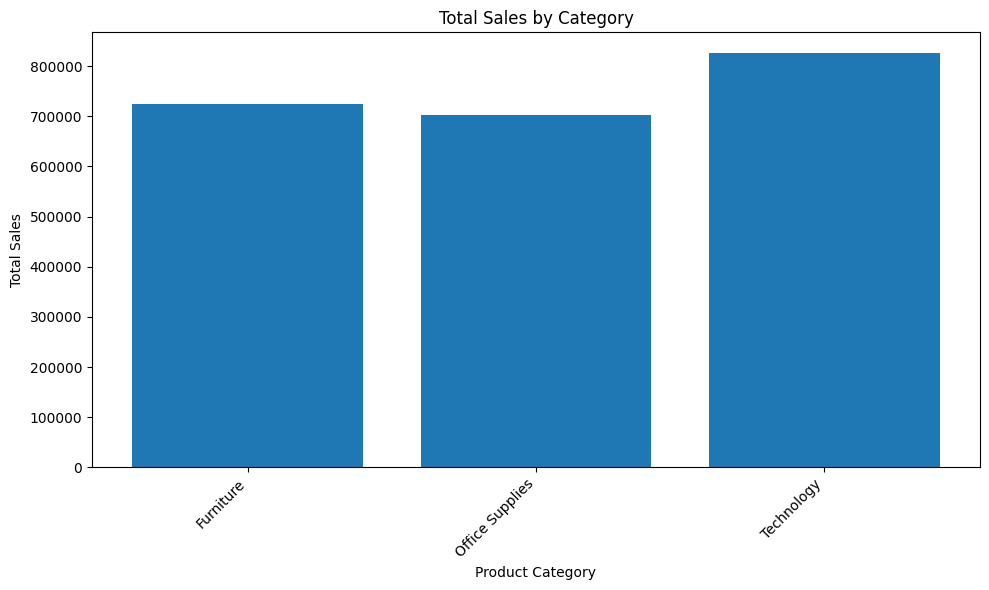

In [49]:
# Create a simple plot and save it using the pyplot interface

# Group the data by 'Category' and calculate the sum of 'Sales' for each.
category_sales = df_orders.groupby('Category')['Sales'].sum()

# We create a figure with plt.figure() to then save it. Plotting functions
# will operate on the 'current' figure and axes.
plt.figure(figsize=(10, 6))

# Create a bar plot using plt.bar()
plt.bar(category_sales.index, category_sales.values)


# Set title and labels for clarity
plt.title('Total Sales by Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

# Rotate x-axis labels if they are long, for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the figure to a file
plt.savefig('total_sales_by_category.png')

# Display the plot as well
plt.show()

### Multiple Figures

Sometimes you might want to create completely separate plots, each in its own window or file. You can achieve this by creating multiple `Figure` objects.

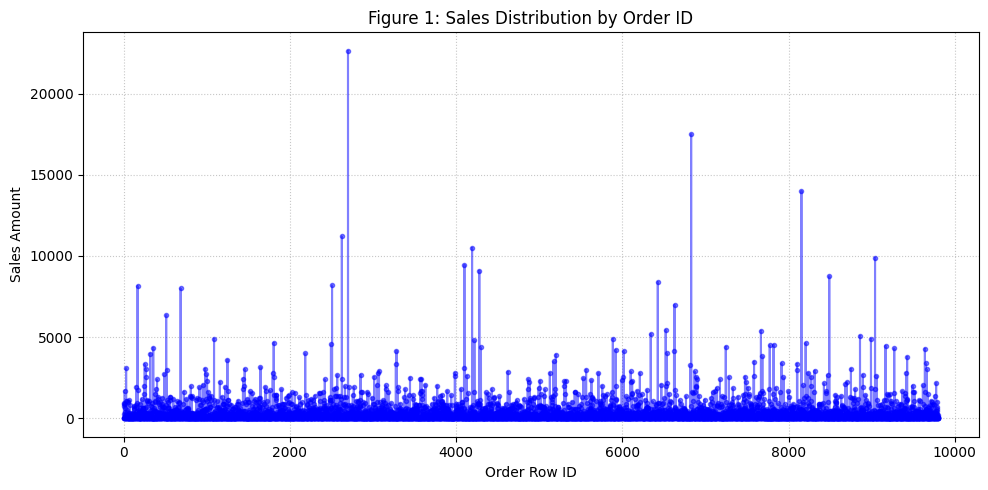

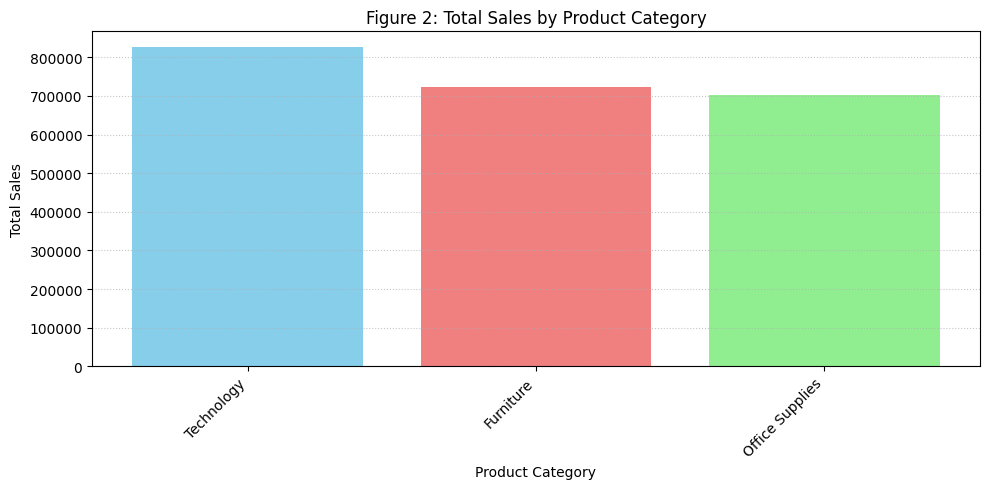

In [50]:
# Create multiple independent figures using the pyplot interface

# First Figure
plt.figure(figsize=(10, 5))
plt.plot(df_orders['Row ID'], df_orders['Sales'], color='blue', marker='o', markersize=3, linestyle='-', alpha=0.5)
plt.title('Figure 1: Sales Distribution by Order ID')
plt.xlabel('Order Row ID')
plt.ylabel('Sales Amount')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout() # Adjust layout for the first figure

# Second Figure
plt.figure(figsize=(10, 5))
category_sales = df_orders.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.bar(category_sales.index, category_sales.values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Figure 2: Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout() # Adjust layout for the second figure

# Display all open figures
plt.show()

# 4. Basic Charts in Matplotlib

Now that we understand the fundamentals of Matplotlib, let's explore some of the most common and useful chart types. For each chart, we'll cover its purpose, suitable data, advantages, limitations, business use cases, and provide a practical Python example using our `df_orders` Superstore dataset.

## Line Chart

### Purpose
Line charts display trends over a continuous period, typically time, showing how a quantitative variable changes.

### When to Use
*   **Time Series Data**: Ideal for tracking changes over dates, months, or years (e.g., sales over time, stock prices).
*   **Ordered Data**: When the sequence of data points is important.

### Considerations
*   **Advantages**: Excellent for showing trends and comparisons over time.
*   **Limitations**: Can get cluttered with too many lines; not for categorical data.

### Business Use Cases
*   Tracking monthly/quarterly sales, stock price movements, website traffic, profit evolution.

### Python Example: Monthly Sales Trend
Let's visualize the trend of total sales over time. We'll convert 'Order Date' to datetime and group by month.

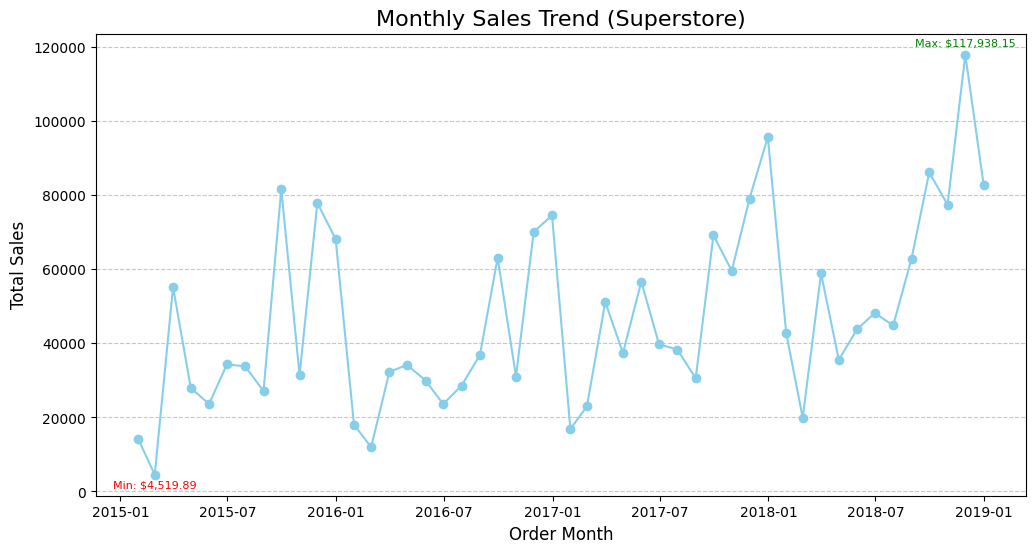

In [51]:
# Group by month and sum the sales
monthly_sales = df_orders.set_index('Order Date')['Sales'].resample('ME').sum() # Use 'ME' for month end

# Create a figure for the plot
plt.figure(figsize=(12, 6))

# Plot the monthly sales data using plt.plot()
plt.plot(monthly_sales.index, monthly_sales.values, color='skyblue', marker='o', linestyle='-')

# Add title and labels using plt.title(), plt.xlabel(), plt.ylabel()
plt.title('Monthly Sales Trend (Superstore)', fontsize=16)
plt.xlabel('Order Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Add a grid for better readability using plt.grid()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add annotations for maximum and minimum sales points (Business example)
max_sales_month = monthly_sales.idxmax()
min_sales_month = monthly_sales.idxmin()
max_sales_value = monthly_sales.max()
min_sales_value = monthly_sales.min()

# Annotate the max sales point using plt.annotate()
plt.annotate(f'Max: ${max_sales_value:,.2f}', xy=(max_sales_month, max_sales_value+2500),
            ha='center', fontsize=8, color='green')

# Annotate the min sales point using plt.annotate()
plt.annotate(f'Min: ${min_sales_value:,.2f}', xy=(min_sales_month, min_sales_value-3500),
            ha='center', fontsize=8, color='red')

# Display the plot
plt.show()

## Bar Chart

### Purpose
Bar charts compare quantities across different categories. The length of each bar shows the numerical value for that category.

### When to Use
*   **Categorical Data**: For comparing numerical values (sums, averages) across distinct categories (e.g., product categories, regions).

### Considerations
*   **Advantages**: Easy to compare values and show rankings.
*   **Limitations**: Can get cluttered with too many categories; not for continuous trends.

### Business Use Cases
*   Comparing sales/profit by product category, regional sales, customer segment counts.

### Python Example: Total Sales by Product Category
Let's compare the total sales generated by different product categories.

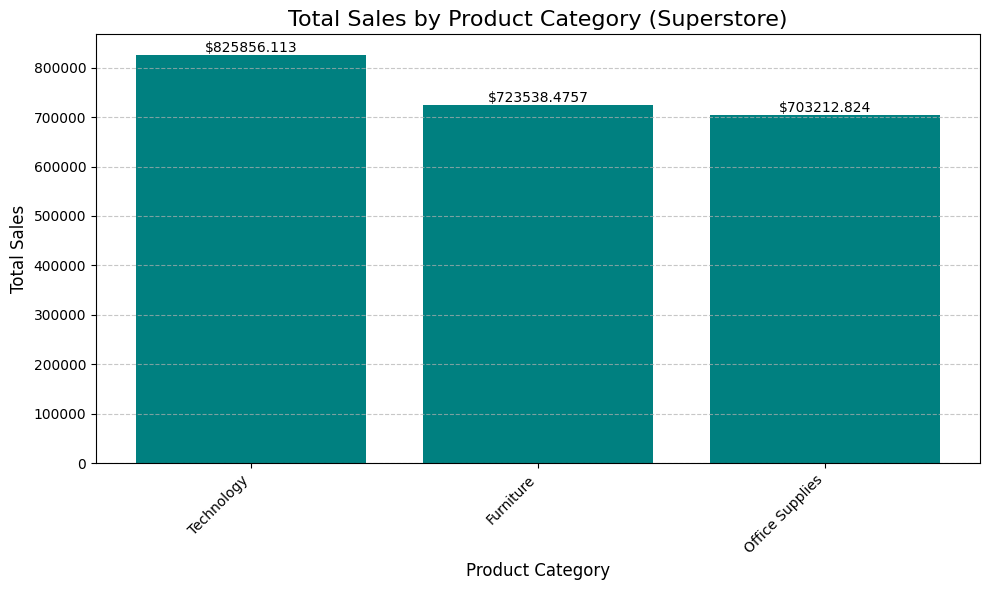

In [52]:
# Group by 'Category' and sum the 'Sales'
category_sales = df_orders.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Create the bar chart using plt.bar()
plt.bar(category_sales.index, category_sales.values, color='teal')

# Add title and labels
plt.title('Total Sales by Product Category (Superstore)', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Rotate x-axis labels if needed for readability
plt.xticks(rotation=45, ha='right')

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of the bars (Business example for precise values)
for i, value in enumerate(category_sales.values):
    plt.text(i, value + 50, f'${value}', ha='center', va='bottom', fontsize=10, color='black')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()

## Horizontal Bar Chart

### Purpose
Horizontal bar charts compare quantities across categories, especially useful for long category names as they provide better readability.

### When to Use
*   **Long Category Labels**: Prevents overcrowding and rotation issues common in vertical bar charts.
*   **Rankings**: Good for visualizing top/bottom N items.

### Considerations
*   **Advantages**: Improved readability for text, clearer rankings.
*   **Limitations**: Not ideal for time-series data; can still be cluttered with too many categories.

### Business Use Cases
*   Showing top 10 products by sales/profit, comparing customer segments, regional sales comparisons.

### Python Example: Top 5 States by Sales
Let's identify and visualize the top 5 states by total sales. (Note: We'll use 'Category' if 'State' is not available in our dataset.)

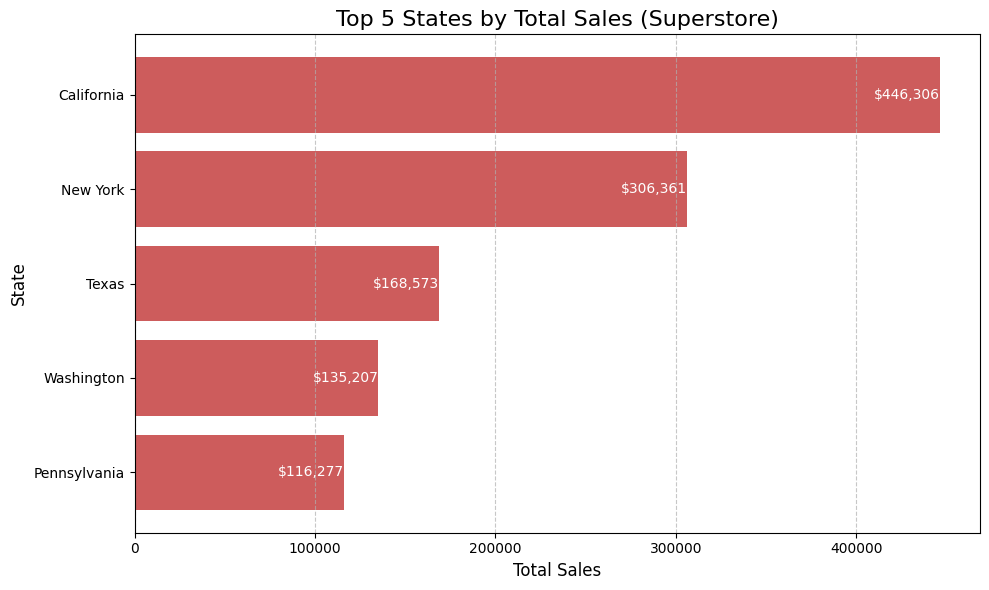

In [53]:
# For demonstration, let's assume we have a 'State' column and group by it.
# If 'State' is not present in the loaded df_orders (e.g., from sample), we'll use 'Category' as a fallback.

# Group by 'State' and sum the 'Sales', then take the top 5
top_states_sales = df_orders.groupby('State')['Sales'].sum().nlargest(5)
title_text = 'Top 5 States by Total Sales (Superstore)'
xlabel_text = 'Total Sales'
ylabel_text = 'State'

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Create the horizontal bar chart using plt.barh()
plt.barh(top_states_sales.index, top_states_sales.values, color='indianred')

# Invert y-axis to have the highest value at the top
plt.gca().invert_yaxis() # plt.gca() gets the current axes and invert_yaxis() is applied to it

# Add title and labels
plt.title(title_text, fontsize=16)
plt.xlabel(xlabel_text, fontsize=12)
plt.ylabel(ylabel_text, fontsize=12)

# Add grid for better readability (vertical lines for x-axis)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add data labels to the end of the bars
for i, value in enumerate(top_states_sales.values):
    plt.text(value + 50, i, f'${value:,.0f}', ha='right', va='center', fontsize=10, color='white')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()

## Scatter Plot

### Purpose
Scatter plots show the relationship between two continuous numerical variables. Each point is an observation.

### When to Use
*   **Two Numerical Variables**: To explore correlations, patterns, or clusters between two quantitative measurements (e.g., sales vs. order ID, or derived metrics).
*   **Outlier Detection**: Good for spotting unusual data points.

### Considerations
*   **Advantages**: Clearly shows relationships (positive, negative, none) and outliers.
*   **Limitations**: Can get messy with too many points (overplotting); not ideal for many variables.

### Business Use Cases
*   Analyzing sales vs. customer ID (to see individual customer purchase patterns), product price vs. number of items sold, advertising spend vs. revenue.

### Python Example: Sales vs. Order Row ID
Let's visualize the relationship between 'Sales' and 'Order Row ID' to see if there's any trend in sales amount as more orders are added.

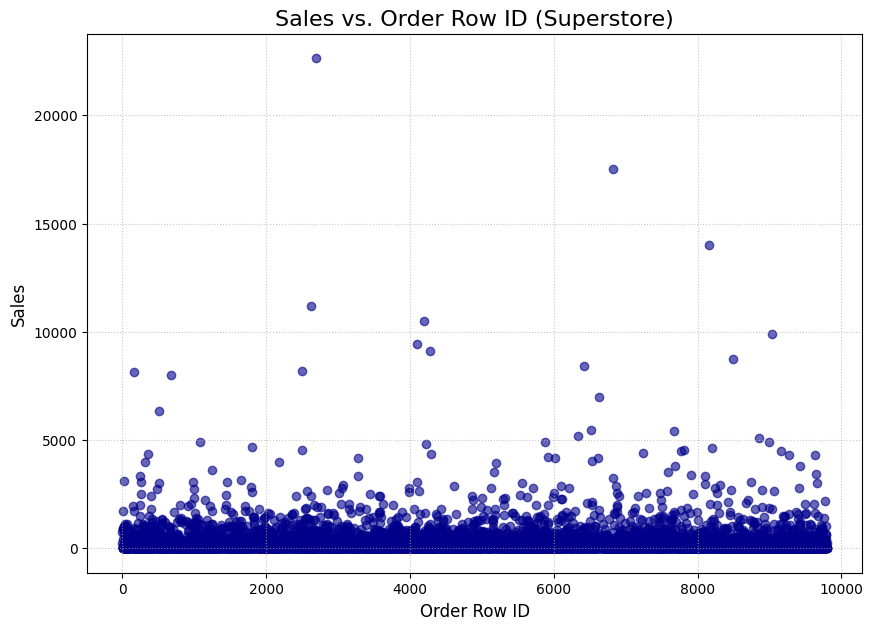

In [54]:
# Create a figure for the plot
plt.figure(figsize=(10, 7))

# Create the scatter plot using plt.scatter()
plt.scatter(x=df_orders['Row ID'], y=df_orders['Sales'], alpha=0.6, color='darkblue')

# Add title and labels
plt.title('Sales vs. Order Row ID (Superstore)', fontsize=16)
plt.xlabel('Order Row ID', fontsize=12)
plt.ylabel('Sales', fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle=':', alpha=0.7)

# Display the plot
plt.show()

## Histogram

### Purpose
Histograms show the distribution of a single continuous numerical variable. They group data into "bins" and display the frequency of values within each bin.

### When to Use
*   **Single Numerical Variable**: To understand the shape, spread, and central tendency of a dataset (e.g., distribution of sales amounts).

### Considerations
*   **Advantages**: Clearly shows data distribution, helps identify outliers.
*   **Limitations**: Can be affected by bin size choice; not for comparing multiple distributions easily.

### Business Use Cases
*   Analyzing customer age distribution, product price ranges, transaction amount frequencies, delivery times.

### Python Example: Distribution of Sales Amounts
Let's examine the distribution of 'Sales' values in our dataset to see common sales amounts.

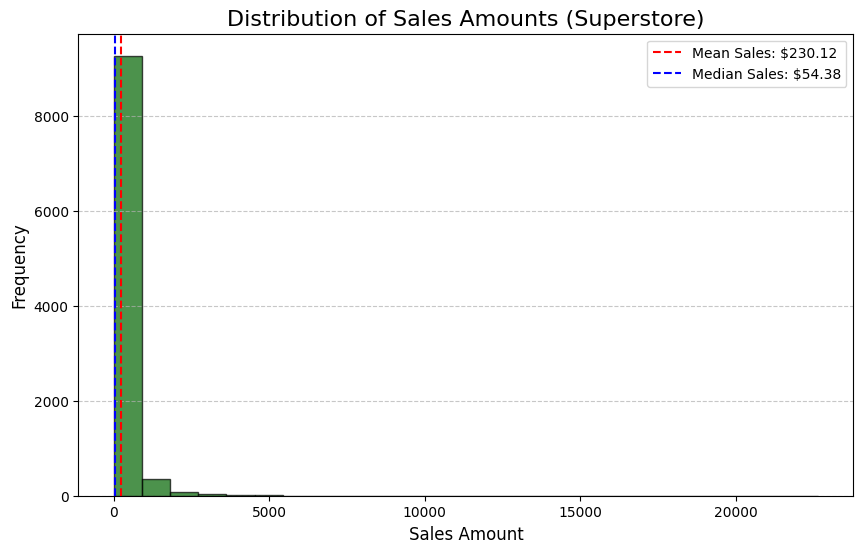

In [55]:
# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Create the histogram using plt.hist()
plt.hist(df_orders['Sales'], bins=25, color='darkgreen', edgecolor='black', alpha=0.7)

# Add title and labels
plt.title('Distribution of Sales Amounts (Superstore)', fontsize=16)
plt.xlabel('Sales Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical line for the mean sales (Business insight)
mean_sales = df_orders['Sales'].mean()
plt.axvline(x=mean_sales, color='red', linestyle='--', label=f'Mean Sales: ${mean_sales:,.2f}')

# Add vertical line for the median sales (Business insight)
median_sales = df_orders['Sales'].median()
plt.axvline(x=median_sales, color='blue', linestyle='--', label=f'Median Sales: ${median_sales:,.2f}')

# Add a legend to explain the mean and median lines
plt.legend()

# Display the plot
plt.show()

## Pie Chart

### Purpose
Pie charts show the proportional distribution of parts within a whole. Each slice represents a category's contribution to the total.

### When to Use
*   **Categorical Data (small number of categories, 2-5)**: Ideal for showing how a few distinct categories make up 100% (e.g., market share).

### Considerations
*   **Advantages**: Intuitive for showing "parts of a whole" concept.
*   **Limitations**: Becomes unreadable with too many slices; difficult for precise comparisons between slices.

### Business Use Cases
*   Displaying market share, budget allocation, customer demographics, or limited sales contributions by category.

### Python Example: Sales Proportion by Product Category
Let's see the proportion of total sales contributed by each product category.

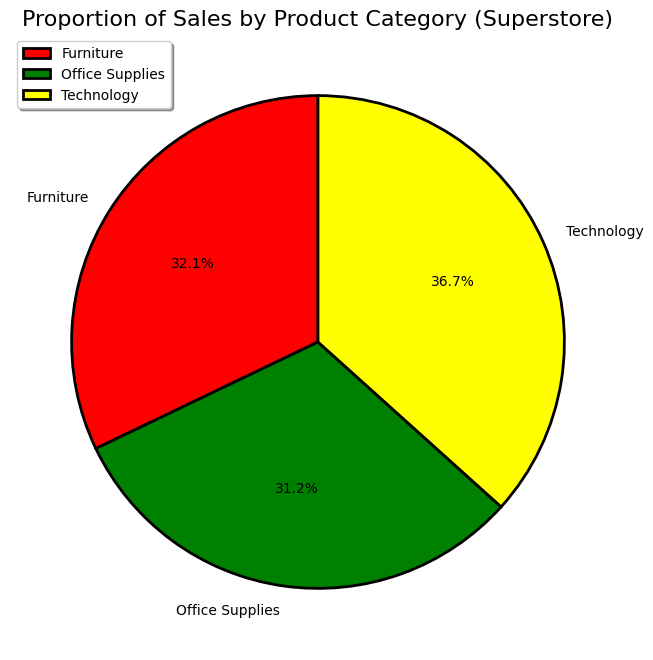

In [56]:
# Group by 'Category' and sum the 'Sales'
category_sales = df_orders.groupby('Category')['Sales'].sum()

# Create a figure for the plot
plt.figure(figsize=(8, 8)) # A square figure is often good for pie charts

# Create the pie chart using plt.pie()
colors = ['red','green','yellow'] # Example custom colors
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', startangle=90,
       colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth':2})

# Add a legend
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

# Add a title
plt.title('Proportion of Sales by Product Category (Superstore)', fontsize=16)

# Display the plot
plt.show()

## Box Plot (Box-and-Whisker Plot)

### Purpose
Box plots show the distribution of numerical data, highlighting the median, quartiles, and outliers. They are excellent for comparing distributions between groups.

### When to Use
*   **Numerical Data**: For summarizing the distribution of one or more variables.
*   **Comparing Groups**: To compare the spread and central tendency of a numerical variable across different categories (e.g., sales across product categories).

### Considerations
*   **Advantages**: Clearly shows five-number summary (min, Q1, median, Q3, max) and outliers. Good for comparisons.
*   **Limitations**: Hides details of the distribution shape; doesn't show data point density.

### Business Use Cases
*   Comparing sales distributions by product segment, analyzing profit margins, visualizing salary distributions.

### Python Example: Sales Distribution by Product Category
Let's use a box plot to examine the distribution of 'Sales' for each product 'Category'.

In [62]:
# q1 = df_orders['Sales'].quantile(0.25)
# q3 = df_orders['Sales'].quantile(0.75)
# iqr = q3 - q1
# lower_bound = q1 - 1.5 * iqr
# upper_bound = q3 + 1.5 * iqr
# df_orders = df_orders[(df_orders['Sales'] > lower_bound) & (df_orders['Sales'] < upper_bound)]

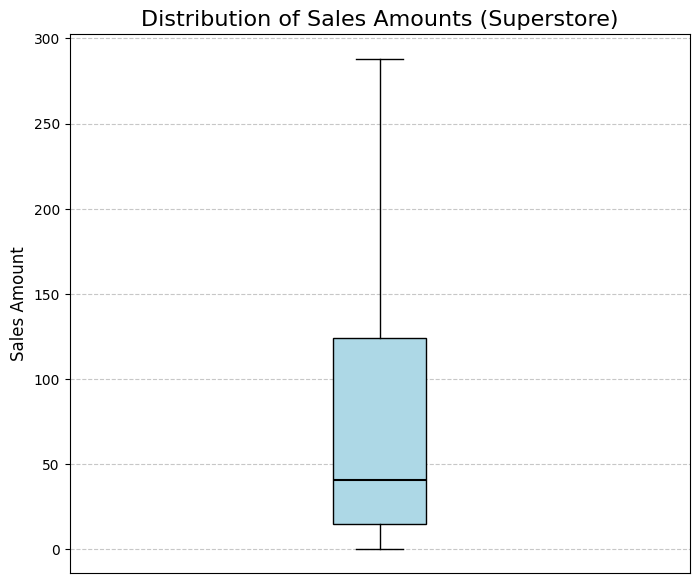

In [61]:
# Create a figure for the plot with a specified size
plt.figure(figsize=(8, 7))

# Create the box plot for the 'Sales' column
# 'patch_artist=True' fills the box with color
# 'medianprops' customizes the median line (black, thicker)
# 'flierprops' customizes outliers (red circles)
# 'boxprops' directly sets the face color of the box
# To hide fliers completely, you can add 'showfliers=False'
plt.boxplot(df_orders['Sales'], patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5),
                     boxprops=dict(facecolor='lightblue'),
                     showfliers=False) # This hides the fliers (red dots)

# Add a title to the plot
plt.title('Distribution of Sales Amounts (Superstore)', fontsize=16)
# Add a label for the y-axis
plt.ylabel('Sales Amount', fontsize=12)

# Remove x-axis tick labels as there is only one box and no specific categories
plt.xticks([])

# Add a horizontal grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the generated plot
plt.show()

# Practice Exercises

Here are some exercises to test your understanding and practice your Matplotlib skills. Use the `df_orders` dataset for all exercises.

1.  **Sales Over Time (Annual Trend)**: Create a line chart showing the total sales for each year. Make sure to label the axes and title appropriately.

2.  **Sales by Sub-Category (Bar Chart)**: Create a vertical bar chart to visualize the total sales for the top 5 product sub-categories. Order the bars from highest to lowest sales. Add data labels to each bar showing the exact sales amount.

3.  **Customer Count by Segment (Horizontal Bar Chart)**: Create a horizontal bar chart showing the count of unique orders for each customer segment. Ensure the category labels are readable.
